## Weather Trend Forecasting

In [ ]:
#Import librairies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import VotingRegressor, StackingRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [3]:
#Loading data

data = pd.read_csv('GlobalWeatherRepository.csv')
data.head(5)

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,8.3,13.3,338,NNW,1012.0,29.89,0.0,0.00,24,30,25.3,77.5,10.0,6.0,7.0,9.5,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,6.9,11.2,320,NW,1012.0,29.88,0.1,0.00,94,75,19.0,66.2,10.0,6.0,5.0,11.4,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,9.4,15.1,280,W,1011.0,29.85,0.0,0.00,29,0,24.6,76.4,10.0,6.0,5.0,13.9,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,7.4,11.9,215,SW,1007.0,29.75,0.3,0.01,61,100,3.8,38.9,2.0,1.0,2.0,8.5,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,8.1,13.0,150,SSE,1011.0,29.85,0.0,0.00,89,50,28.7,83.6,10.0,6.0,8.0,12.5,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [4]:
#Exploring data

data.shape
data.info()
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 141313 entries, 0 to 141312
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       141313 non-null  str    
 1   location_name                 141313 non-null  str    
 2   latitude                      141313 non-null  float64
 3   longitude                     141313 non-null  float64
 4   timezone                      141313 non-null  str    
 5   last_updated_epoch            141313 non-null  int64  
 6   last_updated                  141313 non-null  str    
 7   temperature_celsius           141313 non-null  float64
 8   temperature_fahrenheit        141313 non-null  float64
 9   condition_text                141313 non-null  str    
 10  wind_mph                      141313 non-null  float64
 11  wind_kph                      141313 non-null  float64
 12  wind_degree                   141313 non-null  int64  


,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,141313.000000,141313.000000,1.413130e+05,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000
mean,19.216771,21.939006,1.747298e+09,21.241777,70.236996,7.985739,12.855503,168.850134,1014.044377,29.944126,0.133125,0.005045,66.738410,39.837835,22.095414,71.766404,9.512028,5.619433,3.275568,11.301824,18.190389,452.424026,57.709907,14.854605,10.166634,23.906055,47.829455,1.688896,2.581553,49.985769
std,24.412872,65.783600,1.815260e+07,9.648445,17.367076,7.138014,11.484222,103.696435,10.209145,0.301422,0.556650,0.022002,23.807931,34.083620,11.552303,20.791825,2.689930,1.679902,3.538630,8.515860,13.704863,746.738078,30.494178,23.413298,34.965384,36.345737,147.441210,0.934407,2.425411,35.022592
min,-41.300000,-175.200000,1.715849e+09,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,27.960000,0.000000,0.000000,2.000000,0.000000,-36.700000,-34.000000,0.000000,0.000000,0.000000,2.200000,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,4.050300,-6.836100,1.731661e+09,15.600000,60.000000,3.800000,6.100000,80.000000,1010.000000,29.830000,0.000000,0.000000,51.000000,0.000000,15.600000,60.200000,10.000000,6.000000,0.100000,6.300000,10.200000,196.900000,38.000000,1.750000,1.110000,7.030000,9.850000,1.000000,1.000000,15.000000
50%,17.250000,23.236100,1.747300e+09,23.700000,74.700000,6.700000,10.800000,161.000000,1013.000000,29.930000,0.000000,0.000000,72.000000,29.000000,25.100000,77.200000,10.000000,6.000000,1.800000,9.500000,15.300000,288.600000,55.000000,5.700000,2.405000,14.050000,19.700000,1.000000,2.000000,50.000000
75%,40.400000,49.882200,1.762933e+09,28.000000,82.300000,11.000000,17.600000,256.000000,1018.000000,30.060000,0.020000,0.000000,86.000000,75.000000,29.900000,85.800000,10.000000,6.000000,6.000000,15.000000,24.100000,453.250000,73.000000,17.150000,8.140000,27.380000,41.048000,2.000000,3.000000,85.000000
max,64.150000,179.220000,1.778740e+09,79.300000,174.700000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,42.240000,1.660000,100.000000,100.000000,81.300000,178.300000,32.000000,19.000000,16.300000,1845.700000,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


In [5]:
#Handling missing values

data.isnull().sum()

country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Ni

In [6]:
# Correction

data['last_updated'] = pd.to_datetime(data['last_updated'])

data = data.drop_duplicates()
data = data.replace(['na', 'None', 'NULL'], np.nan)

data.dropna(inplace=True)

print("Updated Data")
print(data[['last_updated', 'location_name', 'temperature_celsius', 'condition_text']].head())

print("\n Updated DataFrame Information")
print(data.info())

Updated Data
         last_updated     location_name  temperature_celsius condition_text
0 2024-05-16 13:15:00             Kabul                 26.6  Partly Cloudy
1 2024-05-16 10:45:00            Tirana                 19.0  Partly cloudy
2 2024-05-16 09:45:00           Algiers                 23.0          Sunny
3 2024-05-16 10:45:00  Andorra La Vella                  6.3  Light drizzle
4 2024-05-16 09:45:00            Luanda                 26.0  Partly cloudy

 Updated DataFrame Information
<class 'pandas.DataFrame'>
RangeIndex: 141313 entries, 0 to 141312
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   country                       141313 non-null  str           
 1   location_name                 141313 non-null  str           
 2   latitude                      141313 non-null  float64       
 3   longitude                     141313 non-null  float64     

In [7]:
# Processing & Feature Engineering

data['hour'] = data['last_updated'].dt.hour
data['day'] = data['last_updated'].dt.day
data['month'] = data['last_updated'].dt.month
data['day_of_week'] = data['last_updated'].dt.dayofweek

data['temp_comfort_diff'] = data['feels_like_celsius'] - data['temperature_celsius']

data['total_particulates'] = data['air_quality_PM2.5'] + data['air_quality_PM10']

print("Feature Engineering Complete:")
print(data[['last_updated', 'hour', 'month', 'temp_comfort_diff', 'total_particulates']].head())

Feature Engineering Complete:
         last_updated  hour  month  temp_comfort_diff  total_particulates
0 2024-05-16 13:15:00    13      5               -1.3                35.0
1 2024-05-16 10:45:00    10      5                0.0                 3.1
2 2024-05-16 09:45:00     9      5                1.6                28.8
3 2024-05-16 10:45:00    10      5               -2.5                 1.6
4 2024-05-16 09:45:00     9      5                2.7               445.7


In [8]:
weather_categorical_cols = ['condition_text', 'wind_direction', 'moon_phase']

data = pd.get_dummies(data, columns=weather_categorical_cols, drop_first=True)
print("One-hot encoding complete. New shape of data:", data.shape)

One-hot encoding complete. New shape of data: (141313, 114)


In [9]:
data.describe()

,latitude,longitude,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination,hour,day,month,day_of_week,temp_comfort_diff,total_particulates
count,141313.000000,141313.000000,1.413130e+05,141313,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000,141313.000000
mean,19.216771,21.939006,1.747298e+09,2025-05-15 10:48:58.372973,21.241777,70.236996,7.985739,12.855503,168.850134,1014.044377,29.944126,0.133125,0.005045,66.738410,39.837835,22.095414,71.766404,9.512028,5.619433,3.275568,11.301824,18.190389,452.424026,57.709907,14.854605,10.166634,23.906055,47.829455,1.688896,2.581553,49.985769,10.863700,15.712043,6.537665,3.005010,0.853637,71.735510
min,-41.300000,-175.200000,1.715849e+09,2024-05-16 01:45:00,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,27.960000,0.000000,0.000000,2.000000,0.000000,-36.700000,-34.000000,0.000000,0.000000,0.000000,2.200000,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,-12.500000,-1208.975000
25%,4.050300,-6.836100,1.731661e+09,2024-11-15 05:00:00,15.600000,60.000000,3.800000,6.100000,80.000000,1010.000000,29.830000,0.000000,0.000000,51.000000,0.000000,15.600000,60.200000,10.000000,6.000000,0.100000,6.300000,10.200000,196.900000,38.000000,1.750000,1.110000,7.030000,9.850000,1.000000,1.000000,15.000000,8.000000,8.000000,4.000000,1.000000,-0.600000,17.200000
50%,17.250000,23.236100,1.747300e+09,2025-05-15 11:00:00,23.700000,74.700000,6.700000,10.800000,161.000000,1013.000000,29.930000,0.000000,0.000000,72.000000,29.000000,25.100000,77.200000,10.000000,6.000000,1.800000,9.500000,15.300000,288.600000,55.000000,5.700000,2.405000,14.050000,19.700000,1.000000,2.000000,50.000000,11.000000,16.000000,7.000000,3.000000,0.000000,34.040000
75%,40.400000,49.882200,1.762933e+09,2025-11-12 14:30:00,28.000000,82.300000,11.000000,17.600000,256.000000,1018.000000,30.060000,0.020000,0.000000,86.000000,75.000000,29.900000,85.800000,10.000000,6.000000,6.000000,15.000000,24.100000,453.250000,73.000000,17.150000,8.140000,27.380000,41.048000,2.000000,3.000000,85.000000,14.000000,23.000000,10.000000,5.000000,2.400000,70.115000
max,64.150000,179.220000,1.778740e+09,2026-05-14 19:30:00,79.300000,174.700000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,42.240000,1.660000,100.000000,100.000000,81.300000,178.300000,32.000000,19.000000,16.300000,1845.700000,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000,23.000000,31.000000,12.000000,6.000000,17.900000,6590.440000
std,24.412872,65.783600,1.815260e+07,NaN,9.648445,17.367076,7.138014,11.484222,103.696435,10.209145,0.301422,0.556650,0.022002,23.807931,34.083620,11.552303,20.791825,2.689930,1.679902,3.538630,8.515860,13.704863,746.738078,30.494178,23.413298,34.965384,36.345737,147.441210,0.934407,2.425411,35.022592,4.746718,8.811421,3.449241,1.991032,2.688187,173.211756


In [ ]:
# Handling outliers

cols_to_check = ['temperature_celsius', 'wind_kph', 'pressure_mb', 'precip_mm']

for col in cols_to_check:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    print(f"Detected {len(outliers)} outliers in {col}")

Detected 1989 outliers in temperature_celsius
Detected 2416 outliers in wind_kph
Detected 4160 outliers in pressure_mb
Detected 28660 outliers in precip_mm


In [11]:
# Normalisation

num_weather_cols = [
    'temperature_celsius', 'wind_kph', 'pressure_mb', 
    'precip_mm', 'humidity', 'cloud', 'visibility_km', 
    'uv_index', 'gust_kph', 'air_quality_PM2.5'
]

scaler = MinMaxScaler()
data[num_weather_cols] = scaler.fit_transform(data[num_weather_cols])

print("Current range of numerical features:")
print(data[num_weather_cols].agg(['min', 'max']))

Current range of numerical features:
     temperature_celsius  wind_kph  pressure_mb  precip_mm  humidity  cloud  \
min                  0.0       0.0          0.0        0.0       0.0    0.0   
max                  1.0       1.0          1.0        1.0       1.0    1.0   

     visibility_km  uv_index  gust_kph  air_quality_PM2.5  
min            0.0       0.0       0.0                0.0  
max            1.0       1.0       1.0                1.0  


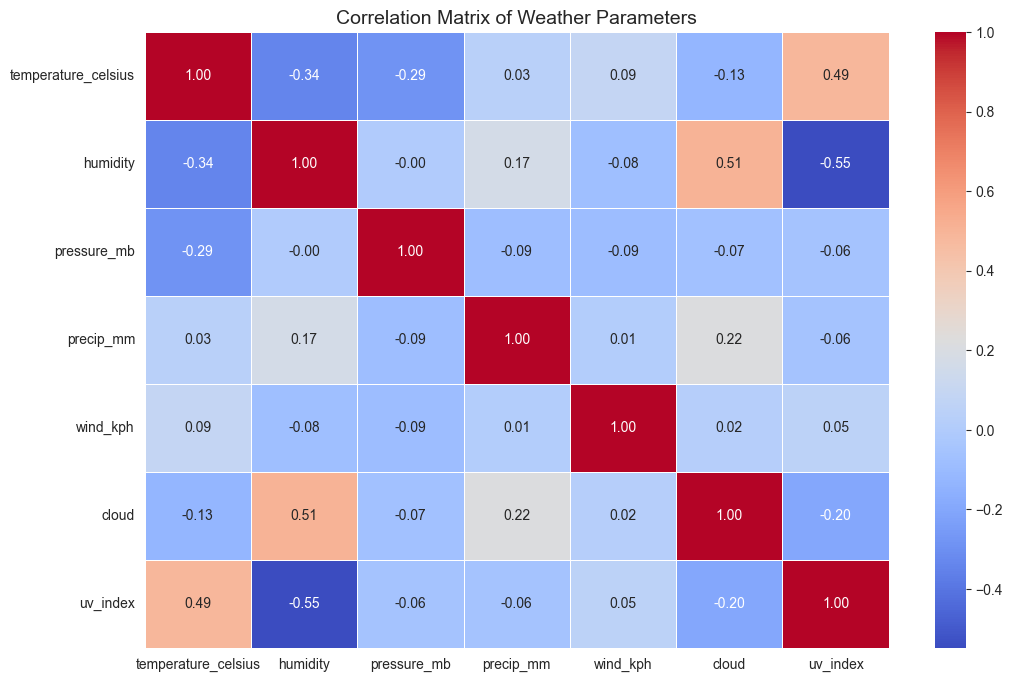

In [12]:
# Correlation Analysis
plt.figure(figsize=(12, 8))

correlation_cols = ['temperature_celsius', 'humidity', 'pressure_mb', 'precip_mm', 'wind_kph', 'cloud', 'uv_index']
correlation_matrix = data[correlation_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Weather Parameters', fontsize=14)
plt.show()

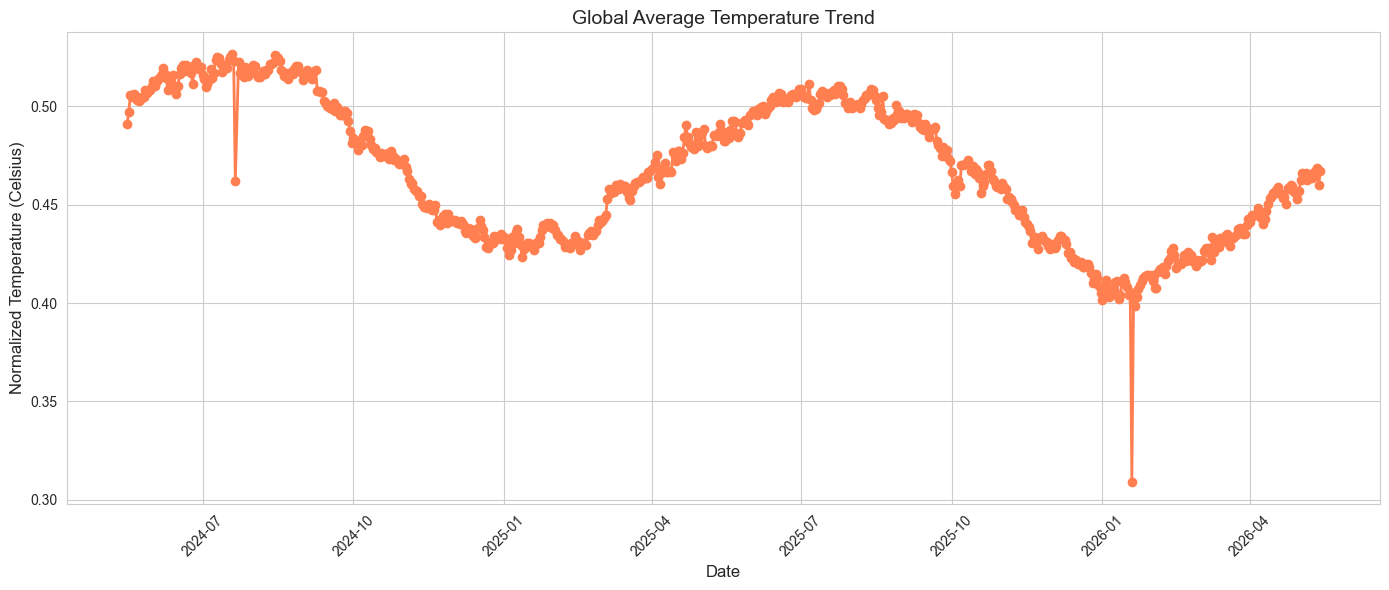

In [13]:
data['last_updated'] = pd.to_datetime(data['last_updated'])

plt.figure(figsize=(14, 6))

df_trends = data.sort_values('last_updated')
daily_temp = df_trends.groupby(df_trends['last_updated'].dt.date)['temperature_celsius'].mean()

plt.plot(daily_temp.index, daily_temp.values, color='coral', marker='o', linestyle='-', linewidth=2)
plt.title('Global Average Temperature Trend', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Normalized Temperature (Celsius)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

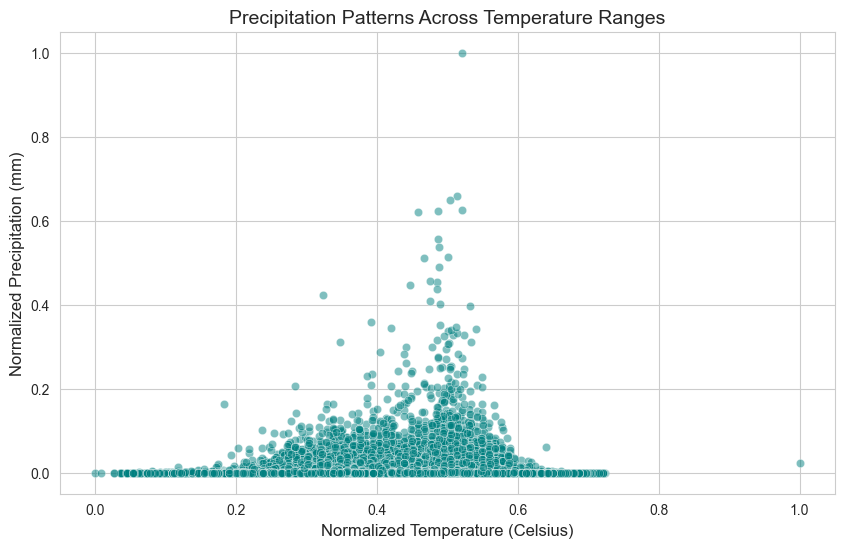

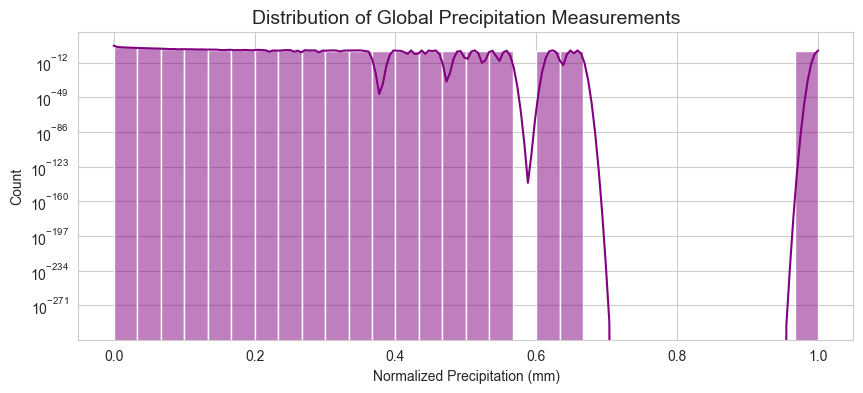

In [14]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x='temperature_celsius', y='precip_mm', data=data, alpha=0.5, color='teal')
plt.title('Precipitation Patterns Across Temperature Ranges', fontsize=14)
plt.xlabel('Normalized Temperature (Celsius)', fontsize=12)
plt.ylabel('Normalized Precipitation (mm)', fontsize=12)
plt.show()

plt.figure(figsize=(10, 4))
sns.histplot(data['precip_mm'], bins=30, kde=True, color='purple')
plt.title('Distribution of Global Precipitation Measurements', fontsize=14)
plt.xlabel('Normalized Precipitation (mm)')
plt.yscale('log') 
plt.show()

Anomaly Detection Summary:
anomaly_label
Normal     139899
Anomaly      1414
Name: count, dtype: int64
Percentage of anomalies detected: 1.00%


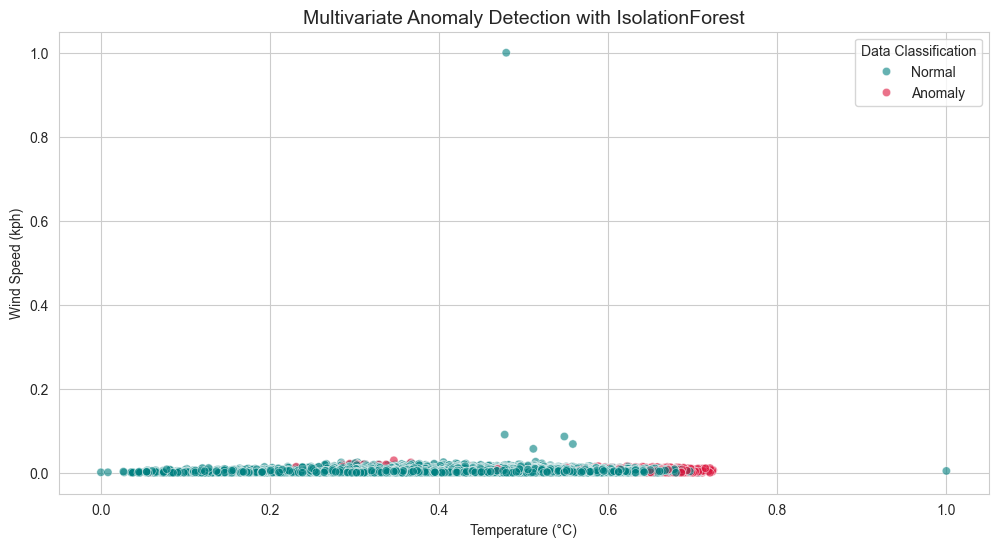


Statistical Profile Comparison
anomaly_label           Anomaly     Normal
temperature_celsius    0.555688   0.466956
wind_kph               0.006160   0.003097
pressure_mb            0.029933   0.032588
humidity               0.223054   0.665018
uv_index               0.469772   0.198238
air_quality_PM10     981.747319  38.390075


In [15]:
# Anomaly detection using IsolationForest

# Clean data corruption placeholders
corrupted_cols = ['air_quality_Carbon_Monoxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5']
for col in corrupted_cols:
    if col in data.columns:
        data[col] = data[col].replace(-9999.0, np.nan)
        data[col] = data[col].fillna(data[col].median())

if 'air_quality_PM2.5' in data.columns and 'air_quality_PM10' in data.columns:
    data['total_particulates'] = data['air_quality_PM2.5'] + data['air_quality_PM10']

# Select key features for multivariate anomaly detection
features_for_anomaly = [
    'temperature_celsius', 'wind_kph', 'pressure_mb', 
    'humidity', 'uv_index', 'air_quality_PM10'
]

features_to_use = [col for col in features_for_anomaly if col in data.columns]
anomaly_data = data[features_to_use].copy()

# Initialize and fit the IsolationForest model
iso_forest = IsolationForest(contamination=0.01, random_state=42)
data['anomaly_flag'] = iso_forest.fit_predict(anomaly_data)

data['anomaly_label'] = data['anomaly_flag'].map({1: 'Normal', -1: 'Anomaly'})

# Analyze the results
anomaly_counts = data['anomaly_label'].value_counts()
print("Anomaly Detection Summary:")
print(anomaly_counts)

if 'Anomaly' in anomaly_counts:
    percentage = (anomaly_counts['Anomaly'] / len(data)) * 100
    print(f"Percentage of anomalies detected: {percentage:.2f}%")
else:
    print("Percentage of anomalies detected: 0.00%")

# Visualize Anomalies
plt.figure(figsize=(12, 6))
sns.scatterplot(
    x='temperature_celsius', 
    y='wind_kph', 
    hue='anomaly_label', 
    palette={'Normal': 'teal', 'Anomaly': 'crimson'}, 
    alpha=0.6, 
    data=data
)
plt.title('Multivariate Anomaly Detection with IsolationForest', fontsize=14)
plt.xlabel('Temperature (°C)')
plt.ylabel('Wind Speed (kph)')
plt.legend(title='Data Classification')
plt.show()

# Statistical Comparison
print("\nStatistical Profile Comparison")
print(data.groupby('anomaly_label')[features_to_use].mean().T)

In [16]:
# Machine Learning train/test split

data = data.sort_values('last_updated')
target = 'temperature_celsius'

cols_to_drop = [
    target, 'temperature_fahrenheit', 'feels_like_celsius', 'feels_like_fahrenheit',
    'last_updated', 'location_name', 'country', 'timezone', 
    'sunrise', 'sunset', 'moonrise', 'moonset', 'last_updated_epoch', 'temp_comfort_diff'
]

X = data.drop(columns=[col for col in cols_to_drop if col in data.columns], errors='ignore')
y = data[target]

split_idx = int(len(data) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Data splitting complete")
print(f"Training features shape: {X_train.shape} | Training target shape: {y_train.shape}")
print(f"Testing features shape: {X_test.shape}   | Testing target shape: {y_test.shape}")

Data splitting complete
Training features shape: (113050, 102) | Training target shape: (113050,)
Testing features shape: (28263, 102)   | Testing target shape: (28263,)


In [17]:
X_train.dtypes

latitude                      float64
longitude                     float64
wind_mph                      float64
wind_kph                      float64
wind_degree                     int64
                               ...   
moon_phase_Waning Gibbous        bool
moon_phase_Waxing Crescent       bool
moon_phase_Waxing Gibbous        bool
anomaly_flag                    int64
anomaly_label                     str
Length: 102, dtype: object

Training Individual: Ridge Regression...
Training Individual: Random Forest...
Training Individual: Gradient Boosting...
Training Ensemble: Voting Regressor...
Training Ensemble: Stacking Regressor...

Final Model Leaderboard
                                    MAE      RMSE        R2
Ensemble: Stacking Regressor   0.024752  0.035966  0.869650
Individual: Random Forest      0.025804  0.037665  0.857041
Individual: Gradient Boosting  0.027842  0.040144  0.837608
Ensemble: Voting Regressor     0.032824  0.045952  0.787219
Individual: Ridge Regression   0.058093  0.075361  0.427693


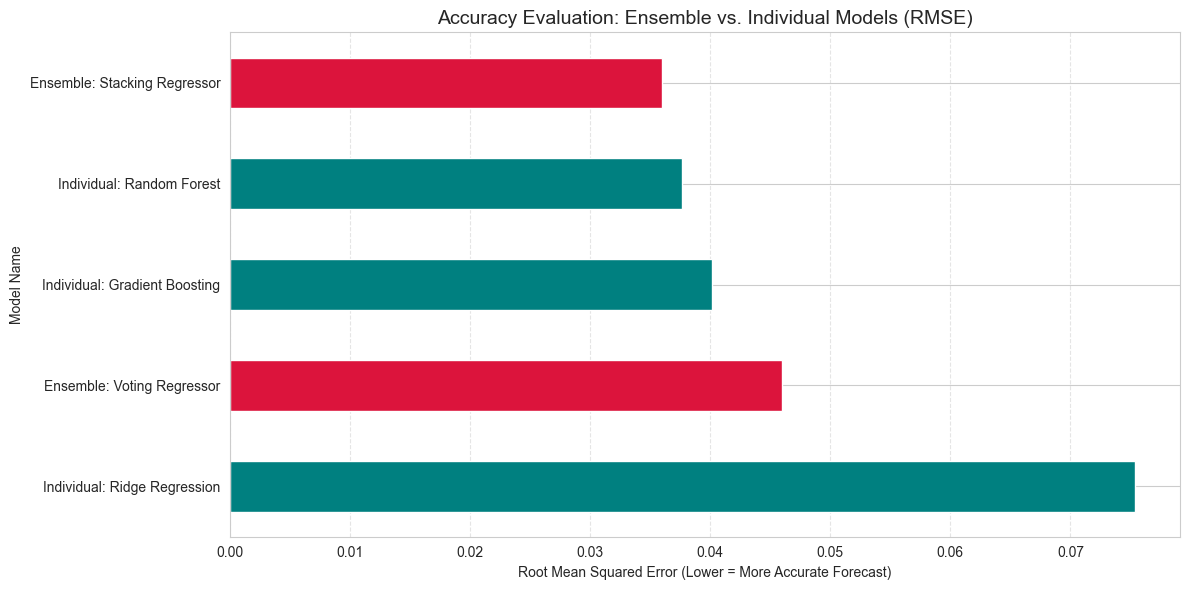

In [18]:
# Assemble of models for accuracy improvement

base_models = [
    ('rf', RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)),
    ('gb', GradientBoostingRegressor(random_state=42)),
    ('ridge', Ridge(alpha=1.0))
]

voting_ensemble = VotingRegressor(estimators=base_models)

stacking_ensemble = StackingRegressor(
    estimators=base_models,
    final_estimator=LinearRegression(),
    cv=5,
    n_jobs=-1
)

all_models = {
    'Individual: Ridge Regression': Ridge(alpha=1.0),
    'Individual: Random Forest': RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    'Individual: Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Ensemble: Voting Regressor': voting_ensemble,
    'Ensemble: Stacking Regressor': stacking_ensemble
}

ensemble_results = {}

X_train_numeric = X_train.select_dtypes(include=[np.number])
X_test_numeric = X_test.select_dtypes(include=[np.number])

for name, model in all_models.items():
    print(f"Training {name}...")
    model.fit(X_train_numeric, y_train)
    y_pred = model.predict(X_test_numeric)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    ensemble_results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

df_ensemble_results = pd.DataFrame(ensemble_results).T.sort_values(by='RMSE')
print("\nFinal Model Leaderboard")
print(df_ensemble_results)

plt.figure(figsize=(12, 6))
colors = ['crimson' if 'Ensemble' in idx else 'teal' for idx in df_ensemble_results.index]

df_ensemble_results['RMSE'].plot(kind='barh', color=colors)
plt.title('Accuracy Evaluation: Ensemble vs. Individual Models (RMSE)', fontsize=14)
plt.xlabel('Root Mean Squared Error (Lower = More Accurate Forecast)')
plt.ylabel('Model Name')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

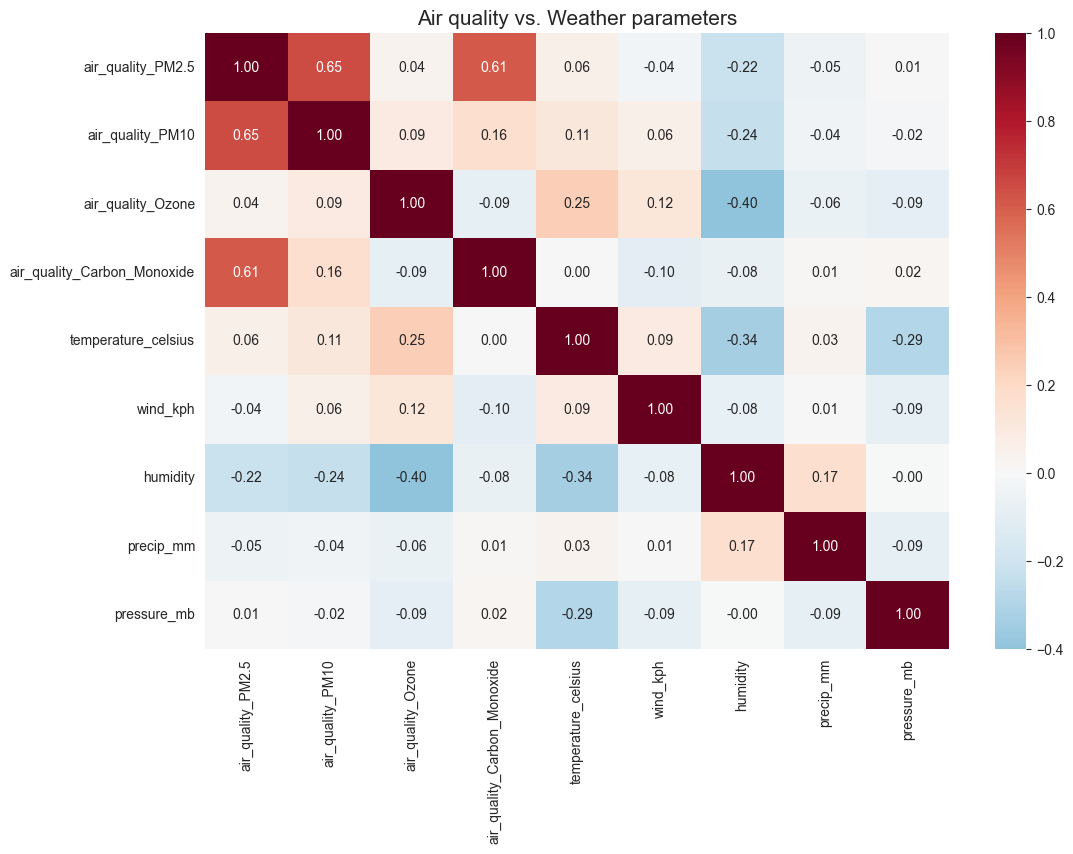

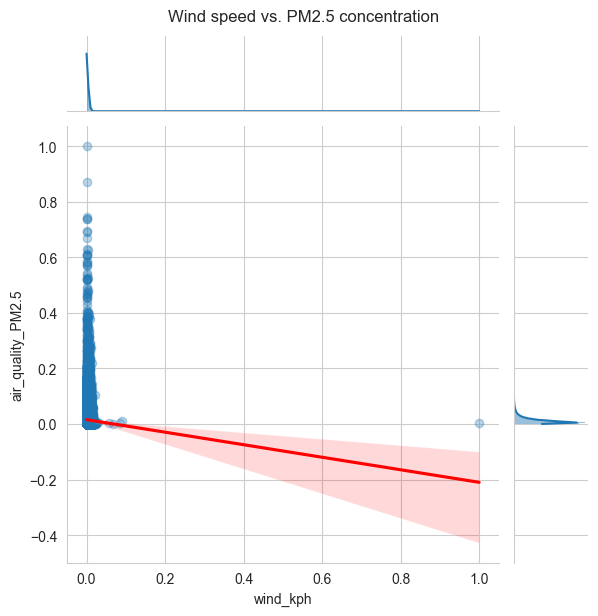

In [19]:
# Environmental impact

# Analyzing air quality
air_quality_cols = ['air_quality_PM2.5', 'air_quality_PM10', 'air_quality_Ozone', 'air_quality_Carbon_Monoxide']
weather_params = ['temperature_celsius', 'wind_kph', 'humidity', 'precip_mm', 'pressure_mb']

env_correlation = data[air_quality_cols + weather_params].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(env_correlation, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Air quality vs. Weather parameters', fontsize=15)
plt.show()

# Analyzing wind speed
sns.jointplot(x='wind_kph', y='air_quality_PM2.5', data=data, kind='reg', 
              joint_kws={'line_kws':{'color':'red'}}, scatter_kws={'alpha':0.3})

plt.suptitle('Wind speed vs. PM2.5 concentration', y=1.02)
plt.show()

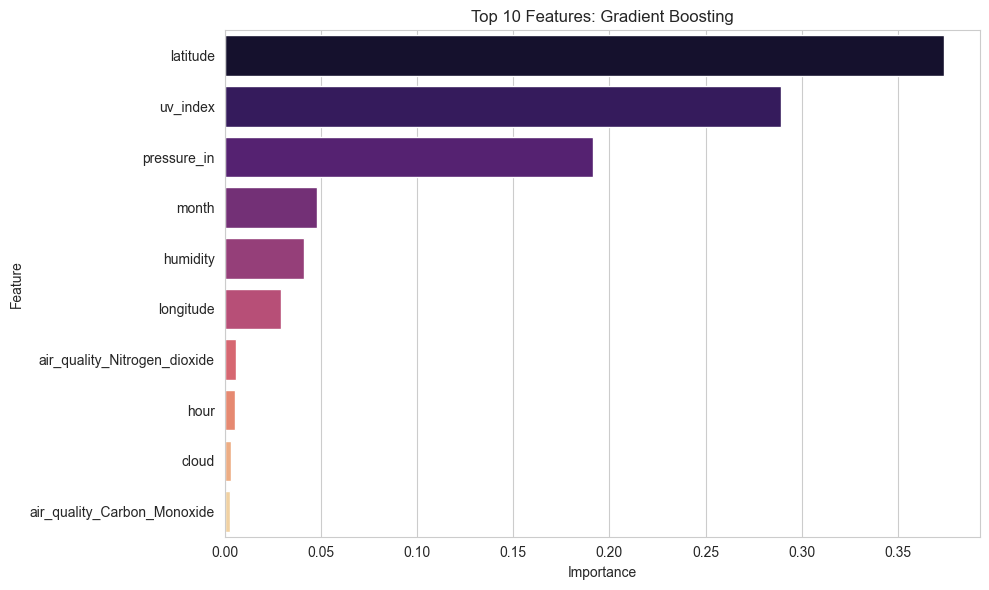

Calculating permutation importance...


C:\Users\Mitson informatique\AppData\Local\Temp\ipykernel_8288\2764786911.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


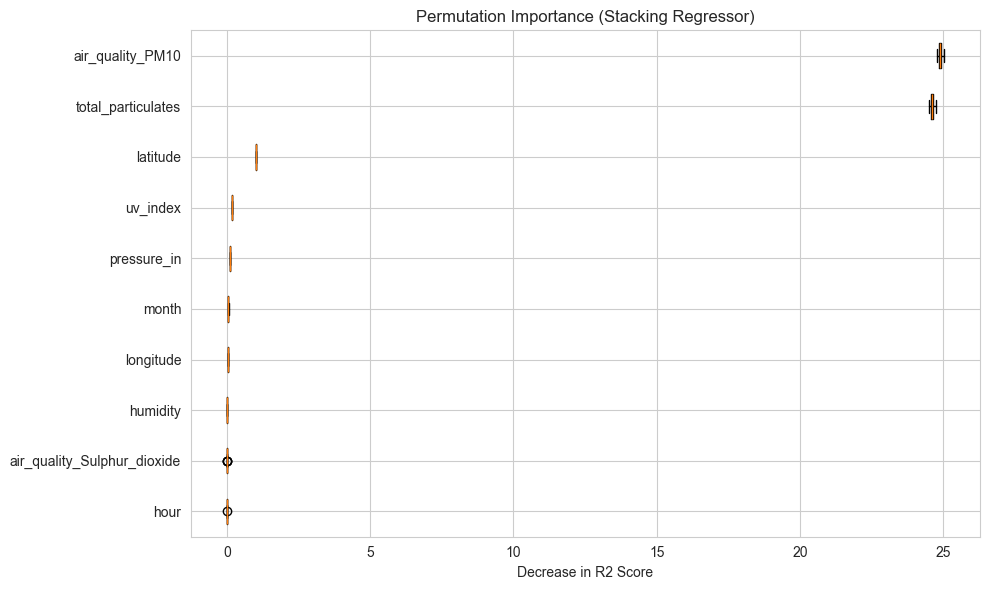

In [22]:
# Model-specific
gb_model = all_models['Individual: Gradient Boosting']

importances = gb_model.feature_importances_
feature_names = X_train_numeric.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df.head(10), 
    palette='magma', 
    hue='Feature', 
    legend=False
)
plt.title('Top 10 Features: Gradient Boosting')
plt.tight_layout()
plt.show()


# Model-agnostic
print("Calculating permutation importance...")

result = permutation_importance(
    all_models['Ensemble: Stacking Regressor'], 
    X_test_numeric, y_test, 
    n_repeats=10, 
    random_state=42
)

perm_sorted_idx = result.importances_mean.argsort()[-10:]

plt.figure(figsize=(10, 6))
plt.boxplot(
    result.importances[perm_sorted_idx].T, 
    vert=False, 
    labels=X_test_numeric.columns[perm_sorted_idx]
)
plt.title("Permutation Importance (Stacking Regressor)")
plt.xlabel("Decrease in R2 Score")
plt.tight_layout()
plt.show()

Spatial coordinates identified: (latitude, longitude)


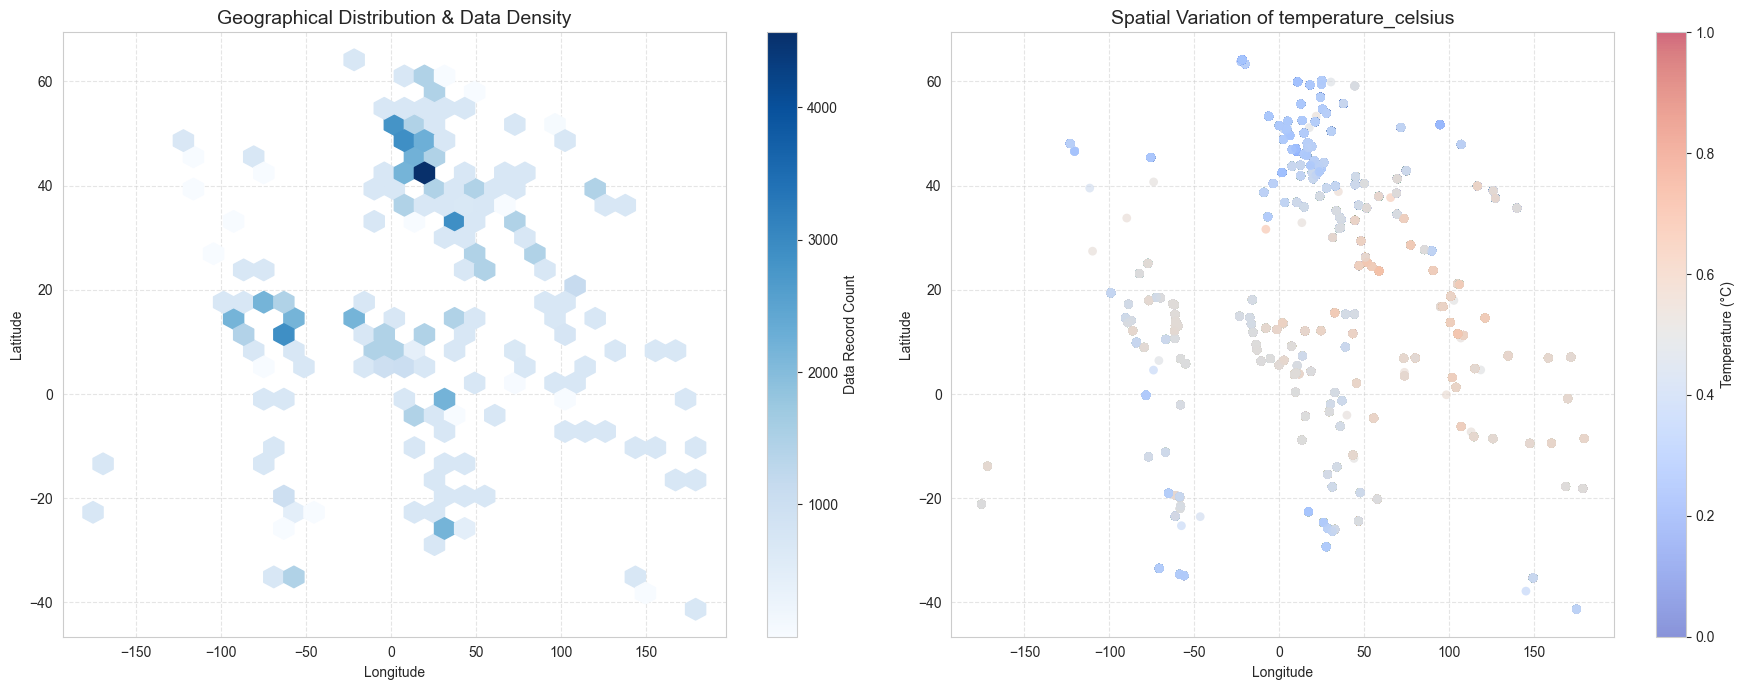


Spatial Correlation with Temperature Baseline:
latitude    -0.387086
longitude    0.138975
Name: temperature_celsius, dtype: float64


In [23]:
# Spatial analysis

lat_col = 'latitude' if 'latitude' in data.columns else 'lat' if 'lat' in data.columns else None
lon_col = 'longitude' if 'longitude' in data.columns else 'lon' if 'lon' in data.columns else None
target_col = 'temperature_celsius'

if lat_col and lon_col:
    print(f"Spatial coordinates identified: ({lat_col}, {lon_col})")
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    hb = axes[0].hexbin(
        data[lon_col], 
        data[lat_col], 
        gridsize=30, 
        cmap='Blues', 
        mincnt=1
    )
    fig.colorbar(hb, ax=axes[0], label='Data Record Count')
    axes[0].set_title('Geographical Distribution & Data Density', fontsize=14)
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')
    axes[0].grid(True, linestyle='--', alpha=0.5)

    sc = axes[1].scatter(
        data[lon_col], 
        data[lat_col], 
        c=data[target_col], 
        cmap='coolwarm', 
        alpha=0.6, 
        edgecolors='none', 
        s=40
    )
    fig.colorbar(sc, ax=axes[1], label='Temperature (°C)')
    axes[1].set_title(f'Spatial Variation of {target_col}', fontsize=14)
    axes[1].set_xlabel('Longitude')
    axes[1].set_ylabel('Latitude')
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
 
    spatial_corr = data[[lat_col, lon_col, target_col]].corr()[target_col].drop(target_col)
    print("\nSpatial Correlation with Temperature Baseline:")
    print(spatial_corr)